In [3]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import re

In [2]:
#Load IMDB Dataset
# keep top 10,000 words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [3]:
#Convert to Vector
def vectorize(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1
    return results

X_train = vectorize(X_train)
X_test = vectorize(X_test)

In [4]:
#Build Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(10000,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')   # binary output
])

C:\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
#Compile Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [6]:
#Train Model
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=512,
                    validation_split=0.2)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7589 - loss: 0.5623 - val_accuracy: 0.8722 - val_loss: 0.3922
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9027 - loss: 0.2962 - val_accuracy: 0.8878 - val_loss: 0.2895
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9287 - loss: 0.2065 - val_accuracy: 0.8936 - val_loss: 0.2766
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9458 - loss: 0.1607 - val_accuracy: 0.8916 - val_loss: 0.2798
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9578 - loss: 0.1302 - val_accuracy: 0.8870 - val_loss: 0.2976


In [27]:
#Evaluate Model
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8757 - loss: 0.3326
Accuracy: 0.8756800293922424


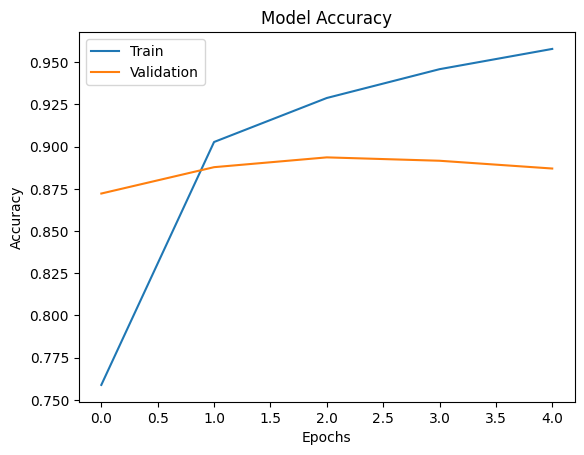

In [7]:
#Plot Graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [8]:
# Predict probabilities
y_pred = model.predict(X_test)

# Convert to 0/1
predicted_labels = (y_pred > 0.5).astype(int).flatten()
true_labels = y_test

# -------- Classification Report --------
report = metrics.classification_report(
    true_labels,
    predicted_labels,
    target_names=['Negative', 'Positive']
)

print(report)


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

    Negative       0.86      0.90      0.88     12500
    Positive       0.90      0.85      0.87     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [22]:
vocab_size = 10000
max_len = 200
# Get word index
word_index = imdb.get_word_index()

# Encode function (FIXED + CLEAN)
def encode_review(text):
    text = re.sub(r'[^\w\s]', '', text.lower())
    words = text.split()

    encoded = [1]  # start token

    for word in words:
        if word in word_index:
            index = word_index[word] + 3  # IMPORTANT FIX
            if index < vocab_size:
                encoded.append(index)
            else:
                encoded.append(2)  # unknown
        else:
            encoded.append(2)  # unknown

    return encoded

# Sample reviews
samples = [
    "This movie was fantastic and amazing",
    "Worst movie I have ever seen",
    "It was okay not great but not bad",
    "Absolutely loved the acting and story",
    "Terrible plot and boring scenes"
]

# Encode + pad
encoded_samples = [encode_review(r) for r in samples]
padded_samples = pad_sequences(encoded_samples, maxlen=max_len)

# Predict
predictions = model.predict(padded_samples)

# Print results
print("\n----- Sample Predictions -----")
for i, review in enumerate(samples):
    print("\nReview:", review)

    if predictions[i][0] > 0.5:
        print("Prediction: Positive")
    else:
        print("Prediction: Negative")

    print("Confidence:", round(predictions[i][0], 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

----- Sample Predictions -----

Review: This movie was fantastic and amazing
Prediction: Positive
Confidence: 0.808

Review: Worst movie I have ever seen
Prediction: Positive
Confidence: 0.58

Review: It was okay not great but not bad
Prediction: Positive
Confidence: 0.614

Review: Absolutely loved the acting and story
Prediction: Positive
Confidence: 0.762

Review: Terrible plot and boring scenes
Prediction: Negative
Confidence: 0.495


Confusion Matrix:
 [[11310  1190]
 [ 1877 10623]]


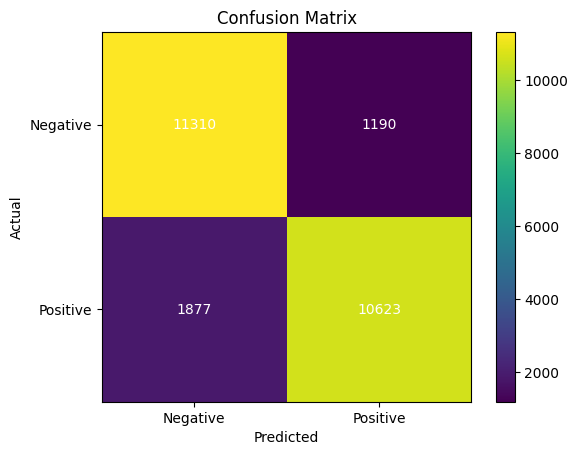

In [10]:
# -------- Confusion Matrix --------
cm = metrics.confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['Negative', 'Positive']
plt.xticks([0,1], classes)
plt.yticks([0,1], classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white')

plt.show()